In [2]:
# Hierarchically-clustered heatmap of MC / non-genotoxic Non-MC JUMP-CP
# morphological profiles - Methods 2.3.2, Figure 2.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


In [3]:
# Per-compound, per-source median profiles (int_ns_h preprocessing variant -
# see data/preprocess_JUMPCP.py), 748 Harmony-corrected features each.
JUMP_DIR = "../../data/processed/int_ns_h/"

# Recover the real Cell Painting feature names (the processed CSVs only
# carry generic harmony_0..harmony_747 column names).
FEATURE_COLS = pd.read_csv("../../data/metadata/jumpcp_int_feature_names.csv")["feature_name"].tolist()

# DATA LOADING

In [4]:
metadata_jumpcp_df = pd.read_csv("../../data/metadata/comp_metadata_jumpcp.csv", low_memory=False)
chemlist_df = pd.read_csv("../../data/chemlist_mc_nomc.csv")

In [5]:
mc_jump_df = pd.read_csv(JUMP_DIR + "mc_jump_profiles.csv", index_col=[0, 1])
nomc_genotox_jump_df = pd.read_csv(JUMP_DIR + "nomc_genotox_jump_profiles.csv", index_col=[0, 1])


In [6]:
# Per-compound median across sources, collapsing multi-source rows to one
# row per compound (MC + non-genotoxic Non-MC only, per Methods 2.3).
combined_mc_nomc_jump_df = pd.concat([mc_jump_df, nomc_genotox_jump_df]).groupby(level=0).median()
combined_mc_nomc_jump_df.columns = FEATURE_COLS

In [7]:
metadata_combined_jumpcp_df = metadata_jumpcp_df[metadata_jumpcp_df["JCP2022"].isin(combined_mc_nomc_jump_df.index.get_level_values('Metadata_JCP2022'))].merge(chemlist_df, left_on="INCHIKEY", right_on="INCHIKEY")[["INCHIKEY", "Category", "Name", "JCP2022", "Genotoxicity", "HormoneSummary"]]

# ClusterMap

In [7]:
metadata_combined_jumpcp_df.loc[metadata_combined_jumpcp_df["Category"] == "NOMC", "Category"] = "Non-MC"

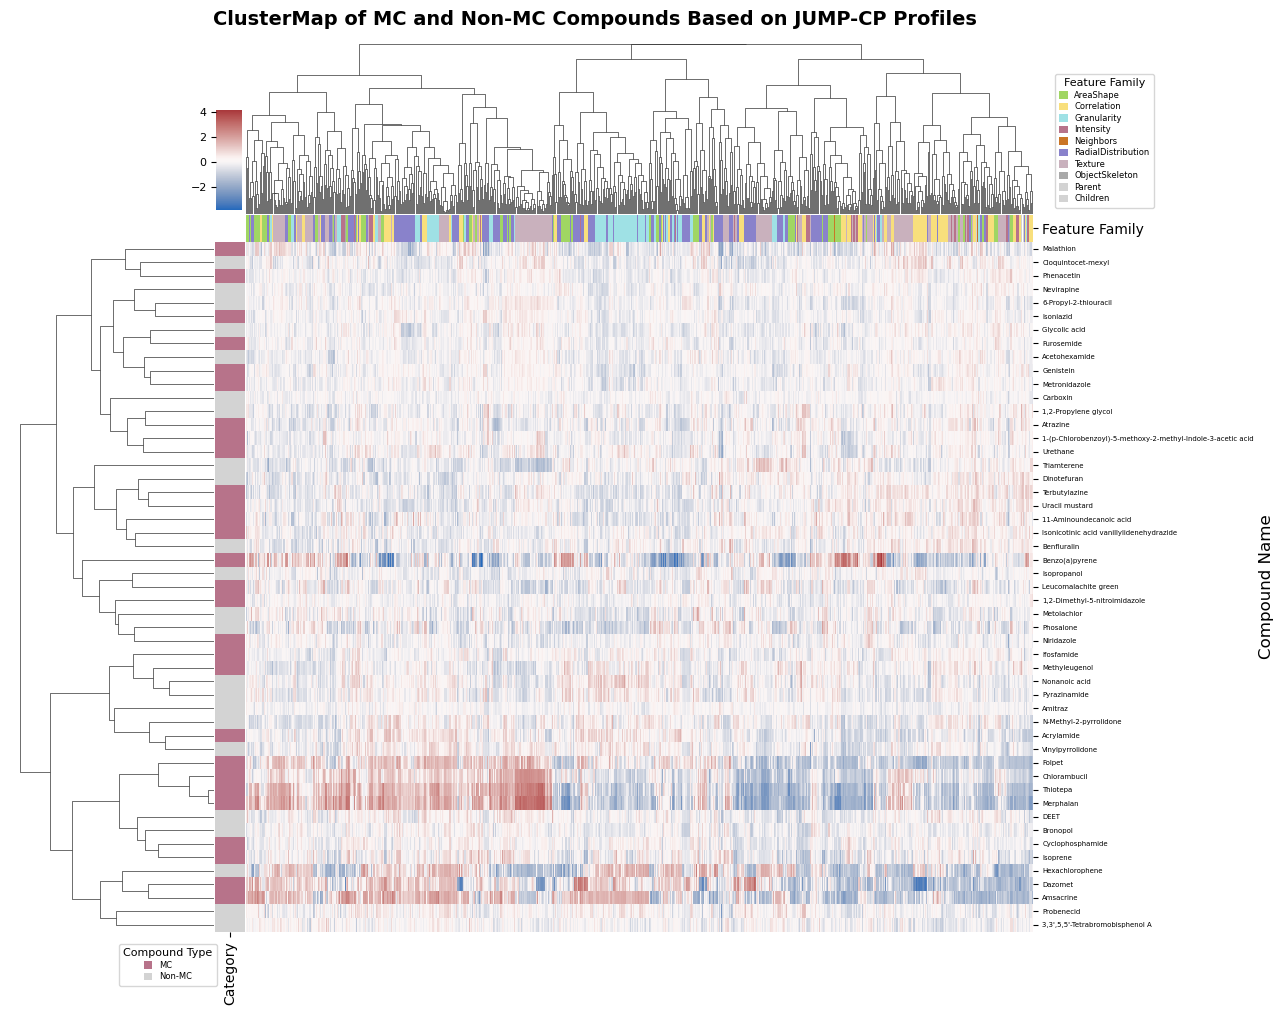

In [8]:
# Figure 2a: ClusterMap colored by compound Category (MC vs Non-MC), with
# feature columns colored by their Cell Painting feature family.
data_transformed = combined_mc_nomc_jump_df.copy()

dico_color_category = {
    'MC': "#B7738A",
    'Non-MC': 'lightgrey',
}

dico_color_channel = {
    'Cells': "#90AE6E",
    'Nuclei': "#E4CF7A",
    'Cytoplasm': "#9FE1E5"}

dico_color_subchannel = {
    'AreaShape': "#A0D663",
    'Correlation': "#F8DF7C",
    'Granularity': "#9FE1E5",
    'Intensity': "#B7738A",
    'Neighbors': "#CA7526",
    'RadialDistribution': "#8982CB",
    'Texture': "#C9B1BD", 
    'ObjectSkeleton': "#A9A9A9",
    'Parent': "#D3D3D3",
    'Children': "#D3D3D3",
}

col_colors_channel=pd.Series(
    [col.split("_")[0] for col in data_transformed.columns],
    index=data_transformed.columns
).map(dico_color_channel)
col_colors_channel.rename("Channel", inplace=True)


col_colors_subchannel=pd.Series(
    [col.split("_")[1] for col in data_transformed.columns],
    index=data_transformed.columns 
).map(dico_color_subchannel)
col_colors_subchannel.rename("Feature Family", inplace=True)

clustmap = sns.clustermap(data=data_transformed, method='complete', metric='correlation', figsize=(12, 10), cmap='vlag',
               row_colors=metadata_combined_jumpcp_df.set_index('JCP2022').loc[data_transformed.index]['Category'].map(dico_color_category), 
               yticklabels=True,
               xticklabels=False,
               cbar_pos=(0.1, 0.81, 0.1, 0.1),  # left bottom width height
               cbar_kws={'ticklocation': 'left'},
               col_cluster=True,
               col_colors=col_colors_subchannel,
)
clustmap.fig.suptitle("ClusterMap of MC and Non-MC Compounds Based on JUMP-CP Profiles", fontsize=14, weight='bold', y=1.01)
clustmap.ax_heatmap.set_yticklabels(metadata_combined_jumpcp_df.set_index('JCP2022').loc[clustmap.data2d.index]['Name'], fontsize=5)
clustmap.ax_heatmap.set_ylabel("Compound Name", fontsize=12)

# Legend: compound category
unique_patches_category = {}
for label, color in dico_color_category.items():
    if color not in unique_patches_category.values():
        unique_patches_category[label] = color

legend_handles = [Patch(facecolor=color, label=label) 
                    for label, color in unique_patches_category.items()]

clustmap.fig.legend(
    handles=legend_handles, 
    title='Compound Type',
    prop={'size': 6},
    title_fontsize=8,
    labelspacing=0.3,
    handlelength=1.0,
    handleheight=1.0,
    borderpad=0.5,
    bbox_to_anchor=(0.1, 0.08),
    loc='upper left',           
    bbox_transform=plt.gcf().transFigure,
    frameon=True
)

# Legend: feature family
legend_handles_subchannel = [Patch(facecolor=color, label=label) 
                           for label, color in dico_color_subchannel.items()]

clustmap.fig.legend(
    handles=legend_handles_subchannel, 
    title='Feature Family',
    prop={'size': 6},
    title_fontsize=8,
    labelspacing=0.3,
    handlelength=1.0,
    handleheight=1.0,
    borderpad=0.5,
    bbox_to_anchor=(0.88, 0.95),
    loc='upper left',           
    bbox_transform=plt.gcf().transFigure,
    frameon=True
)

colorbar = clustmap.ax_heatmap.collections[0].colorbar
colorbar.ax.tick_params(labelsize=8)
colorbar.ax.set_aspect(0.5)
colorbar.ax.set_position([0.145, 0.81, 0.1, 0.1])

plt.savefig("../../figures/ClusterMap_MC_NONMC_JUMPCP.png", dpi=600, bbox_inches='tight')

PATH_OUTPUT_CSV = "../../data/results_tables/clustered_mc_nomc_jump_profiles.csv"
# clustmap.data2d.to_csv("../../data/results_tables/clustered_mc_nomc_jump_profiles.csv")
# --- Compound Names instead of JUMPCP ID ---
# Create copy of dataframe to save, to avoid modifying the original clustmap.data2d
df_to_save = clustmap.data2d.copy()

# Replace the index (JUMPCP IDs) with compound names using the metadata_combined_jumpcp_df
df_to_save.index = metadata_combined_jumpcp_df.set_index('JCP2022').loc[df_to_save.index]['Name']

# Rename the index to "Compound_Name" for clarity
df_to_save.index.name = "Compound_Name"

# Save the modified dataframe to CSV
df_to_save.to_csv(PATH_OUTPUT_CSV)
# ------

plt.show()

In [9]:
clustmap.data2d

,Cells_AreaShape_Zernike_9_5,Cells_AreaShape_EulerNumber,Cells_AreaShape_Zernike_9_1,Nuclei_RadialDistribution_FracAtD_DNA_4of4,Nuclei_AreaShape_Compactness,Nuclei_RadialDistribution_FracAtD_AGP_4of4,Nuclei_RadialDistribution_FracAtD_Mito_4of4,Nuclei_RadialDistribution_FracAtD_RNA_4of4,Cells_AreaShape_Compactness,Nuclei_AreaShape_Zernike_4_2,...,Cells_Count_Count,Nuclei_Parent_NucleiIncludingEdges,Nuclei_RadialDistribution_MeanFrac_ER_4of4,Cytoplasm_Correlation_Manders_ER_DNA,Cytoplasm_Granularity_1_DNA,Cells_Intensity_IntegratedIntensityEdge_DNA,Cytoplasm_Intensity_MinIntensityEdge_DNA,Cytoplasm_Correlation_RWC_AGP_RNA,Cells_Correlation_Manders_AGP_RNA,Cytoplasm_Correlation_Manders_AGP_RNA
Metadata_JCP2022,,,,,,,,,,,,,,,,,,,,,
JCP2022_042812,-0.435585,0.627587,-0.346287,-0.003630,-0.330526,-0.434083,-0.822137,-0.687477,-0.337527,1.128604,...,-0.126798,-0.004821,-0.638161,0.433579,0.042995,-0.528866,-0.324749,-0.502140,-0.815401,-0.013431
JCP2022_012554,0.268917,0.109070,0.381464,-0.197387,-0.712821,-0.588154,-1.116840,0.030808,-0.271928,-0.285855,...,0.124532,0.417556,0.319309,0.371076,0.177867,-0.147789,-0.040321,-0.204508,0.127154,-0.129150
JCP2022_012638,-0.532347,-0.326825,-0.143463,-0.553371,-0.520450,-0.486231,-0.546868,-0.489176,0.208609,-0.368074,...,0.330128,0.102568,-0.148205,-0.233228,0.452161,0.245926,0.258937,-0.257639,0.012266,0.364543
JCP2022_060649,0.027428,-0.077299,-0.062589,-0.163104,0.088476,-0.522450,0.178665,-0.504047,-0.397723,0.020350,...,0.195731,0.642115,-0.065947,0.197332,0.074189,-0.309183,0.001976,0.062643,-0.064718,0.265372
JCP2022_045678,0.095335,-0.008114,0.407733,-0.248284,-0.160284,-0.193843,-0.070375,-0.387031,-0.168763,-0.019298,...,-0.049098,0.184673,-0.879587,-0.163155,-0.182641,-0.512032,-0.309842,-0.358926,-0.537052,-0.334930
JCP2022_075502,-0.423034,0.142051,-0.320002,-0.435112,-0.153554,-0.675295,-0.256805,-0.815543,-0.767766,-0.188328,...,0.076546,0.235989,-0.836063,-0.226409,-0.033230,-0.236868,-0.057926,0.265642,-0.267488,-0.184988
JCP2022_000870,-0.253979,-0.052931,-0.182297,-0.237422,-0.459604,-0.339737,-0.504180,0.031107,-0.475850,-0.195792,...,0.136853,0.666544,0.025815,0.283311,0.266895,0.054416,0.208514,-0.457865,-0.016983,0.044254
JCP2022_116714,0.066476,0.427865,0.656577,-0.380476,-0.303331,-0.560634,-0.322541,-0.386947,-0.488606,-0.528839,...,-0.051237,0.330338,-0.668026,-0.013235,-0.075135,-0.224953,-0.100050,-0.032804,-0.266081,0.205726
JCP2022_093901,-0.361878,-0.679314,-1.126056,-0.654624,-0.551320,-0.796041,-0.705163,-0.841955,-0.445630,-0.277487,...,-0.002830,0.356164,-0.700286,-0.172801,0.433834,-0.180205,0.078639,-0.194232,-0.298303,-0.075030


In [10]:
# Feature-level deviations for the "DEET / Bronopol / Cyclophosphamide /
# Isoprene" subcluster discussed in Results 3.1.2 (Tab. SX).
top10index = clustmap.data2d.iloc[42:46, ].sum().sort_values(ascending=False).head(10).index
bottom10index = clustmap.data2d.iloc[42:46, ].sum().sort_values(ascending=True).head(10).index
display(clustmap.data2d.iloc[42:46, ][top10index].T)
display(clustmap.data2d.iloc[42:46, ][bottom10index].T)

Metadata_JCP2022,JCP2022_055115,JCP2022_051917,JCP2022_012146,JCP2022_080231
Cytoplasm_Correlation_Correlation_ER_RNA,1.068321,0.750370,1.000683,1.145686
Cells_Correlation_Correlation_ER_RNA,1.111719,0.915634,0.962097,0.945005
Cells_Correlation_Overlap_AGP_DNA,0.833279,0.895077,1.004151,1.122324
Nuclei_RadialDistribution_RadialCV_ER_2of4,0.683529,1.227048,0.570886,1.331872
Cytoplasm_Correlation_K_Mito_ER,0.701541,0.597232,0.634596,1.838824
Cells_RadialDistribution_RadialCV_mito_tubeness_1of20,0.994999,0.777517,0.440141,1.538622
Cytoplasm_RadialDistribution_MeanFrac_AGP_4of4,1.004631,0.538277,0.762211,1.437739
Cells_RadialDistribution_RadialCV_RNA_1of4,1.114116,0.439880,0.657130,1.389548
Cells_RadialDistribution_RadialCV_mito_tubeness_1of16,0.852615,0.744943,0.506497,1.476638
Nuclei_RadialDistribution_RadialCV_ER_3of4,0.829993,0.558811,0.831847,1.348905


Metadata_JCP2022,JCP2022_055115,JCP2022_051917,JCP2022_012146,JCP2022_080231
Cytoplasm_RadialDistribution_MeanFrac_AGP_2of4,-1.468807,-0.461151,-0.954001,-1.255167
Cytoplasm_Texture_Contrast_AGP_3_00_256,-1.239557,-0.626642,-0.735937,-1.243707
Nuclei_AreaShape_BoundingBoxMinimum_Y,-0.984624,-0.579181,-0.527307,-1.744949
Cytoplasm_RadialDistribution_MeanFrac_AGP_3of4,-1.171167,-0.489833,-0.890239,-1.270305
Cytoplasm_Texture_Contrast_RNA_3_02_256,-1.408550,-0.744081,-1.026477,-0.588661
Cells_RadialDistribution_MeanFrac_mito_tubeness_17of20,-0.937768,-0.402864,-0.421159,-1.833107
Cells_Correlation_Manders_AGP_DNA,-0.284543,-1.008572,-0.711920,-1.565400
Nuclei_Correlation_K_RNA_Mito,-0.493441,-0.618621,-0.909145,-1.547686
Cells_Correlation_K_ER_Mito,0.060479,-0.785922,-0.930345,-1.774303
Cytoplasm_Texture_Contrast_Mito_3_02_256,-0.151906,-0.834836,-1.032078,-1.360105


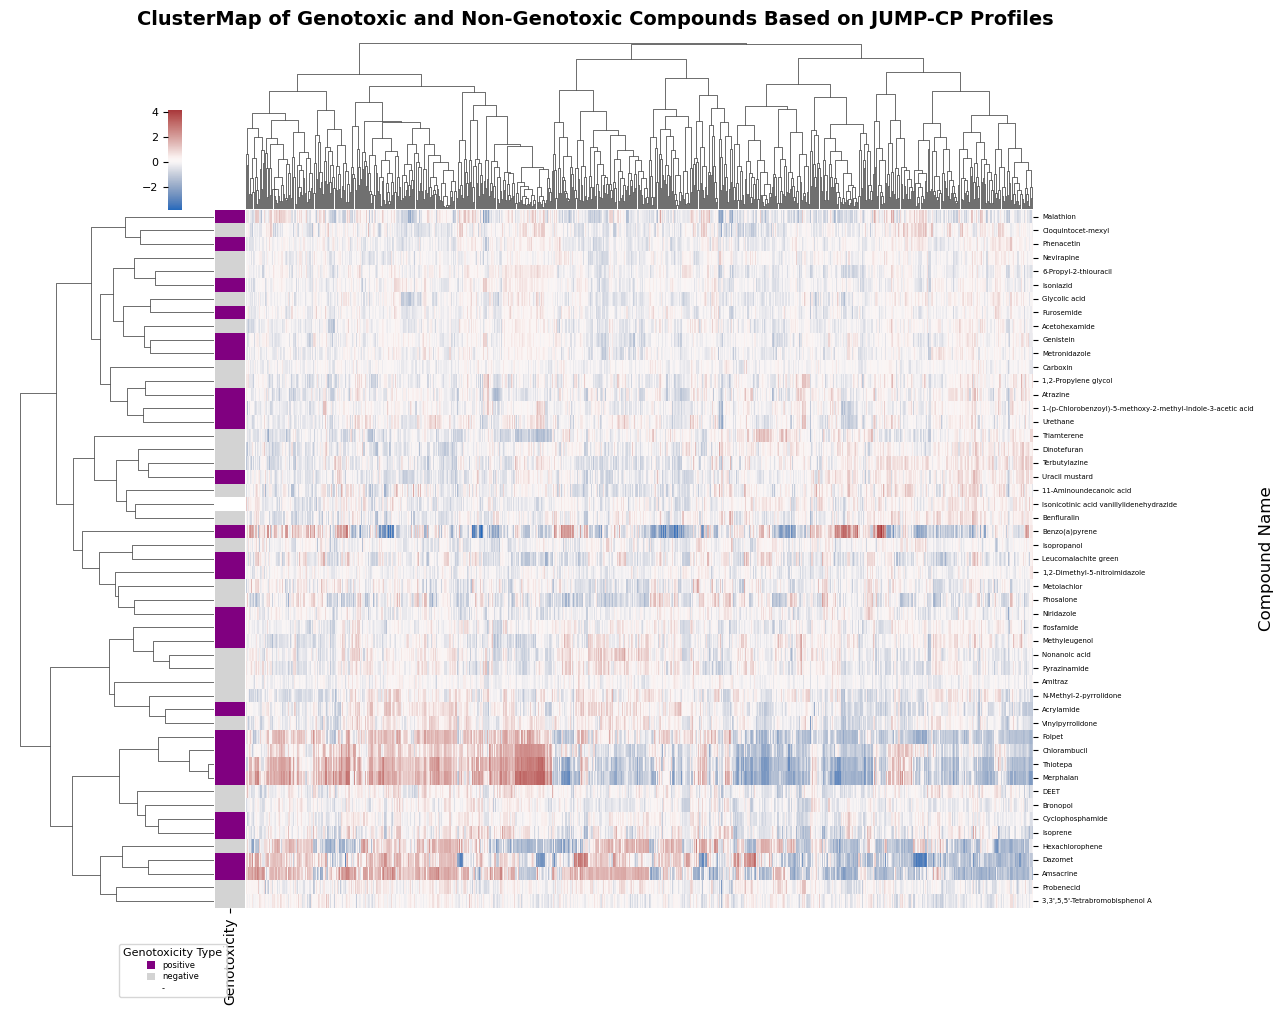

In [11]:
# Supplementary variant: same clustering, rows colored by Genotoxicity
# status instead of Category. Not one of the two panels of Figure 2, kept
# here as an additional exploratory view.
dico_color_geno = {
    'positive': 'purple',
    'negative': 'lightgrey',
    '-' : 'white'
}

clustmap = sns.clustermap(data=data_transformed, method='complete', metric='correlation', figsize=(12, 10), cmap='vlag',
               row_colors=metadata_combined_jumpcp_df.set_index('JCP2022').loc[data_transformed.index]['Genotoxicity'].map(dico_color_geno), 
               yticklabels=True,
               xticklabels=False,
               cbar_pos=(0.1, 0.81, 0.1, 0.1),  # left bottom width height
               cbar_kws={'ticklocation': 'left'},
)
clustmap.fig.suptitle("ClusterMap of Genotoxic and Non-Genotoxic Compounds Based on JUMP-CP Profiles", fontsize=14, weight='bold', y=1.01)
clustmap.ax_heatmap.set_yticklabels(metadata_combined_jumpcp_df.set_index('JCP2022').loc[clustmap.data2d.index]['Name'], fontsize=5)
clustmap.ax_heatmap.set_ylabel("Compound Name", fontsize=12)

unique_patches = {}
for label, color in dico_color_geno.items():
    if color not in unique_patches.values():
        unique_patches[label] = color

legend_handles = [Patch(facecolor=color, label=label) 
                    for label, color in unique_patches.items()]

clustmap.fig.legend(
    handles=legend_handles, 
    title='Genotoxicity Type',
    prop={'size': 6},
    title_fontsize=8,
    labelspacing=0.3,
    handlelength=1.0,
    handleheight=1.0,
    borderpad=0.5,
    bbox_to_anchor=(0.1, 0.08),
    loc='upper left',           
    bbox_transform=plt.gcf().transFigure,
    frameon=True
)

colorbar = clustmap.ax_heatmap.collections[0].colorbar
colorbar.ax.tick_params(labelsize=8)
colorbar.ax.set_aspect(0.9)

plt.savefig("../../figures/ClusterMap_GENOTOX_JUMPCP.png", dpi=600, bbox_inches='tight')

# clustmap.data2d.to_csv("../../data/results_tables/clustered_genotox_jump_profiles.csv")
PATH_OUTPUT_CSV = "../../data/results_tables/clustered_genotox_jump_profiles.csv"
# --- Compound Names instead of JUMPCP ID ---
# Create copy of dataframe to save, to avoid modifying the original clustmap.data2d
df_to_save = clustmap.data2d.copy()

# Replace the index (JUMPCP IDs) with compound names using the metadata_combined_jumpcp_df
df_to_save.index = metadata_combined_jumpcp_df.set_index('JCP2022').loc[df_to_save.index]['Name']

# Rename the index to "Compound_Name" for clarity
df_to_save.index.name = "Compound_Name"

# Save the modified dataframe to CSV
df_to_save.to_csv(PATH_OUTPUT_CSV)


plt.show()

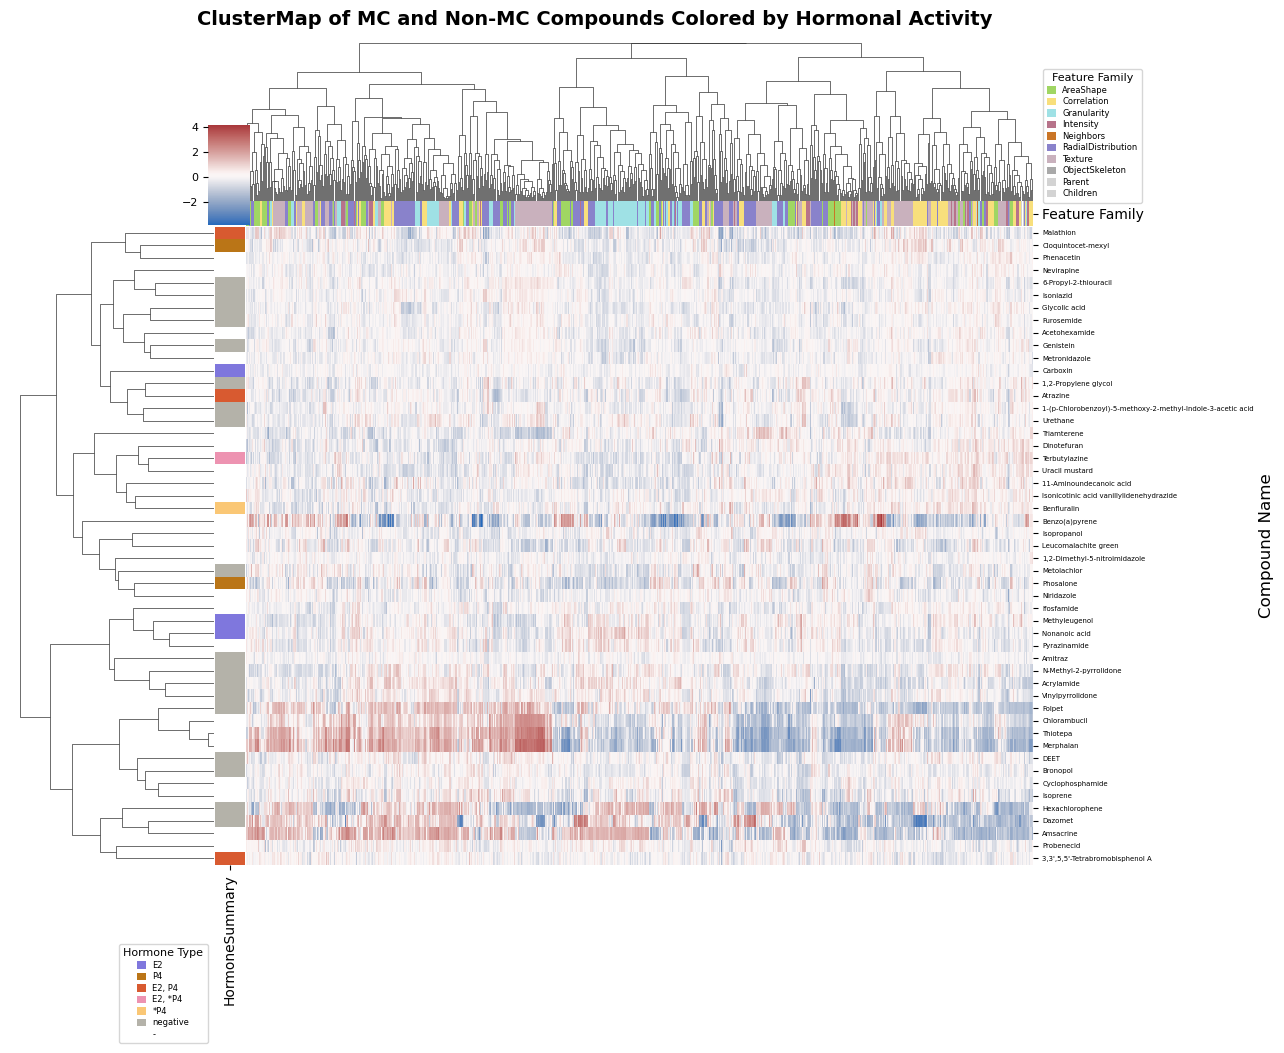

In [12]:
# Figure 2b: same clustering, rows colored by hormonal activity (E2/P4)
# instead of Category.
data_transformed = combined_mc_nomc_jump_df.copy()

dico_color_hormo = {
    'E2':      '#7F77DD',
    'P4':      '#BA7517',
    'E2, P4':  '#D85A30',
    'E2, *P4': '#ED93B1',
    '*P4':     '#FAC775',
    'negative':'#B4B2A9',
    '-':       'white',
}
row_colors = metadata_combined_jumpcp_df.set_index('JCP2022').loc[data_transformed.index]['HormoneSummary'].map(dico_color_hormo)

clustmap = sns.clustermap(data=data_transformed, method='complete', metric='correlation', figsize=(12, 10), cmap='vlag',
               row_colors=row_colors, 
               yticklabels=True,
               xticklabels=False,
               cbar_pos=(0.1, 0.81, 0.1, 0.1),  # left bottom width height
               cbar_kws={'ticklocation': 'left'},
               col_colors=col_colors_subchannel
)
clustmap.fig.suptitle("ClusterMap of MC and Non-MC Compounds Colored by Hormonal Activity", fontsize=14, weight='bold', y=1.01)
clustmap.ax_heatmap.set_yticklabels(metadata_combined_jumpcp_df.set_index('JCP2022').loc[clustmap.data2d.index]['Name'], fontsize=5)
clustmap.ax_heatmap.set_ylabel("Compound Name", fontsize=12)

unique_patches = {}
for label, color in dico_color_hormo.items():
    if color not in unique_patches.values():
        unique_patches[label] = color

legend_handles = [Patch(facecolor=color, label=label) 
                    for label, color in unique_patches.items()]

clustmap.fig.legend(
    handles=legend_handles, 
    title='Hormone Type',
    prop={'size': 6},
    title_fontsize=8,
    labelspacing=0.3,
    handlelength=1.0,
    handleheight=1.0,
    borderpad=0.5,
    bbox_to_anchor=(0.1, 0.08),
    loc='upper left',           
    bbox_transform=plt.gcf().transFigure,
    frameon=True
)

legend_handles_subchannel = [Patch(facecolor=color, label=label) 
                           for label, color in dico_color_subchannel.items()]

clustmap.fig.legend(
    handles=legend_handles_subchannel, 
    title='Feature Family',
    prop={'size': 6},
    title_fontsize=8,
    labelspacing=0.3,
    handlelength=1.0,
    handleheight=1.0,
    borderpad=0.5,
    bbox_to_anchor=(0.87, 0.955),
    loc='upper left',           
    bbox_transform=plt.gcf().transFigure,
    frameon=True
)

colorbar = clustmap.ax_heatmap.collections[0].colorbar
colorbar.ax.tick_params(labelsize=8)
colorbar.ax.set_aspect(0.3)
colorbar.ax.set_position([0.145, 0.795, 0.1, 0.1])

plt.savefig("../../figures/ClusterMap_Hormone_JUMPCP.png", dpi=600, bbox_inches='tight')

PATH_OUTPUT_CSV = "../../data/results_tables/clustered_hormone_jump_profiles.csv"
# --- Compound Names instead of JUMPCP ID ---
# Create copy of dataframe to save, to avoid modifying the original clustmap.data2d
df_to_save = clustmap.data2d.copy()

# Replace the index (JUMPCP IDs) with compound names using the metadata_combined_jumpcp_df
df_to_save.index = metadata_combined_jumpcp_df.set_index('JCP2022').loc[df_to_save.index]['Name']

# Rename the index to "Compound_Name" for clarity
df_to_save.index.name = "Compound_Name"

# Save the modified dataframe to CSV
df_to_save.to_csv(PATH_OUTPUT_CSV)


plt.show()

In [13]:
# Feature-level deviations for the "Hexachlorophene / Dazomet / Amsacrine"
# subcluster discussed in Results 3.1.2 (Tab. SX).
clustmap.data2d.query("Metadata_JCP2022 in ['JCP2022_000438', 'JCP2022_102809', 'JCP2022_077738', 'JCP2022_072255']")

,Cells_AreaShape_Zernike_9_5,Cells_AreaShape_EulerNumber,Cells_AreaShape_Zernike_9_1,Nuclei_RadialDistribution_FracAtD_DNA_4of4,Nuclei_AreaShape_Compactness,Nuclei_RadialDistribution_FracAtD_AGP_4of4,Nuclei_RadialDistribution_FracAtD_Mito_4of4,Nuclei_RadialDistribution_FracAtD_RNA_4of4,Cells_AreaShape_Compactness,Nuclei_AreaShape_Zernike_4_2,...,Cells_Count_Count,Nuclei_Parent_NucleiIncludingEdges,Nuclei_RadialDistribution_MeanFrac_ER_4of4,Cytoplasm_Correlation_Manders_ER_DNA,Cytoplasm_Granularity_1_DNA,Cells_Intensity_IntegratedIntensityEdge_DNA,Cytoplasm_Intensity_MinIntensityEdge_DNA,Cytoplasm_Correlation_RWC_AGP_RNA,Cells_Correlation_Manders_AGP_RNA,Cytoplasm_Correlation_Manders_AGP_RNA
Metadata_JCP2022,,,,,,,,,,,,,,,,,,,,,
JCP2022_077738,0.473612,0.142176,0.051400,0.683894,-0.384955,0.227004,-0.152135,0.137670,0.380738,-0.149868,...,0.019677,0.370203,-0.709205,-0.084104,-0.010785,-0.009418,-0.143554,0.127329,0.090828,-0.269607
JCP2022_000438,-0.111635,0.963488,-0.101961,-0.589445,-0.364440,-1.404774,-2.168260,-2.193718,-0.287425,-1.054122,...,-1.414116,-1.801317,-0.530982,-1.395984,-1.350866,-1.359541,-1.472706,-0.269932,-0.359264,-0.111489
JCP2022_072255,1.000970,1.198091,0.375375,1.744959,1.546651,1.000339,2.319376,0.097763,0.722671,1.963986,...,-1.375701,-1.700909,-1.706784,-1.537991,-1.380353,-1.044024,-1.399162,-0.647003,-1.157853,-0.977555
JCP2022_102809,1.197721,1.135805,1.931670,1.716990,1.726817,1.822215,2.121376,1.485308,1.857833,2.288246,...,-1.575544,-1.782689,-1.680491,-1.495651,-1.382619,-1.632732,-1.627914,-0.828476,-0.708467,-1.511112


In [14]:
# Feature-level profile for Triamterene, discussed as an isolated compound
# in the upper dendrogram branch (Results 3.1.2).
clustmap.data2d.query("Metadata_JCP2022 == 'JCP2022_021857'")

,Cells_AreaShape_Zernike_9_5,Cells_AreaShape_EulerNumber,Cells_AreaShape_Zernike_9_1,Nuclei_RadialDistribution_FracAtD_DNA_4of4,Nuclei_AreaShape_Compactness,Nuclei_RadialDistribution_FracAtD_AGP_4of4,Nuclei_RadialDistribution_FracAtD_Mito_4of4,Nuclei_RadialDistribution_FracAtD_RNA_4of4,Cells_AreaShape_Compactness,Nuclei_AreaShape_Zernike_4_2,...,Cells_Count_Count,Nuclei_Parent_NucleiIncludingEdges,Nuclei_RadialDistribution_MeanFrac_ER_4of4,Cytoplasm_Correlation_Manders_ER_DNA,Cytoplasm_Granularity_1_DNA,Cells_Intensity_IntegratedIntensityEdge_DNA,Cytoplasm_Intensity_MinIntensityEdge_DNA,Cytoplasm_Correlation_RWC_AGP_RNA,Cells_Correlation_Manders_AGP_RNA,Cytoplasm_Correlation_Manders_AGP_RNA
Metadata_JCP2022,,,,,,,,,,,,,,,,,,,,,
JCP2022_021857,0.107476,-0.472136,-0.322986,-0.611408,-0.429874,0.285124,-0.136713,-0.525055,-0.539796,-0.542085,...,0.158035,0.387929,-0.188933,-0.000455,0.253698,-0.05116,0.075512,0.001309,0.869696,0.919034
